# SE322 Lab 2: Advanced BPE Tokenization Tutorial

**Learning Outcomes:**

* Grasp the fundamentals of BPE tokenization.
* Implement and analyze character/subword tokenization.
* Build and track vocabulary growth during BPE training.
* Train a BPE model and encode text

In [ ]:
# Advanced BPE Tokenization Tutorial
# ================================

import torch
import numpy as np
from collections import Counter, defaultdict
from typing import List, Dict, Tuple, Set
import re
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# Checking for GPU Availability

This code snippet checks if a GPU (Graphics Processing Unit) is available on the system and sets the `device` variable accordingly.

**Explanation:**

1. `torch.device('cuda' if torch.cuda.is_available() else 'cpu')`: This line uses the `torch.device` function

In [ ]:
# Check for GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cpu


# Step 1: Basic Text Processing

This section defines a sample corpus of text for demonstrating BPE tokenization.

This step establishes the basic text data that will be used for subsequent steps in the BPE tokenization process. The corpus serves as an example to demonstrate how BPE works on a small set of sentences.

In [ ]:
# Step 1: Basic Text Processing (unchanged)
# =======================================
print("Step 1: Basic Text Processing")
print("-----------------------------")

corpus = [
    "hello world",
    "hello deep learning",
    "deep learning is fun",
    "learning to code"
]

print("Our sample corpus:")
for text in corpus:
    print(f"- {text}")

Step 1: Basic Text Processing
-----------------------------
Our sample corpus:
- hello world
- hello deep learning
- deep learning is fun
- learning to code


# Step 2: Improved Character-Level Tokenization

This code defines a function `get_character_tokens` that performs character-level tokenization with improved handling of special cases.

**How it works:**

1. **Word Boundary Token:** It replaces spaces in the input text with an underscore (`_`) to represent word boundaries.
2. **Special Token Handling:** It preserves any characters specified in the `special_tokens` set (defaulting to `_` and `<UNK>`).
3. **Non-Alphanumeric Handling:** If a character is not alphanumeric and not a special token, it is replaced with `<UNK>` (unknown).
4. **Character Tokenization:** All other characters are treated as individual tokens.

**Example:**

The code includes an example that tokenizes the text "hello world!". It first replaces the space with an underscore, resulting in "hello_world!". Then, it processes each character, preserving the underscore and replacing the exclamation

In [ ]:
# Step 2: Improved Character-Level Tokenization
# ==========================================
print("\nStep 2: Improved Character-Level Tokenization")
print("------------------------------------------")

def get_character_tokens(text: str, special_tokens: Set[str] = {'_', '<UNK>'}) -> List[str]:
    """
    Split text into individual characters with improved handling of special cases.

    Args:
        text: Input text to tokenize
        special_tokens: Set of special tokens to preserve

    Returns:
        List of character tokens
    """
    # Add word boundary token
    text = text.replace(" ", "_")

    # Handle special characters and return as list
    tokens = []
    for char in text:
        if char in special_tokens:
            tokens.append(char)
        elif not char.isalnum():  # Handle non-alphanumeric characters
            tokens.append('<UNK>')
        else:
            tokens.append(char)
    return tokens

# Test improved tokenization
example_text = "hello world!"
char_tokens = get_character_tokens(example_text)
print(f"Original text: {example_text}")
print(f"Character tokens: {char_tokens}")


Step 2: Improved Character-Level Tokenization
------------------------------------------
Original text: hello world!
Character tokens: ['h', 'e', 'l', 'l', 'o', '_', 'w', 'o', 'r', 'l', 'd', '<UNK>']


# Step 3: Enhanced Vocabulary Building with Visualization

This code builds an initial vocabulary of characters from the corpus, including special tokens for unknown words and word boundaries.

* **`VocabularyTracker`:** This class is designed to **track and visualize** how the vocabulary size changes during BPE training. It's important to **monitor this growth** to understand how the BPE algorithm is merging tokens and how the vocabulary is evolving.

* **`update`:** This method is called during training to **record the current vocabulary size** along with the current merge step. This information is **essential for visualizing** the vocabulary growth later.

* **`build_char_vocab`:** This function **creates the initial vocabulary** based on the characters present in the training text. It also includes special tokens like `<UNK>` and `_`. This initial vocabulary **serves as the starting point** for BPE.

* **`get_character_tokens`:**  This function (from a previous step) **breaks down text into individual characters**, handling special cases like word boundaries and unknown characters. It's **essential for creating** the initial vocabulary and for later BPE merging operations.


In [ ]:
# Step 3: Enhanced Vocabulary Building with Visualization
# ==================================================
print("\nStep 3: Enhanced Vocabulary Building")
print("----------------------------------")

class VocabularyTracker:
    """Tracks vocabulary growth and provides visualization."""

    def __init__(self):
        self.vocab_sizes = []
        self.merge_steps = []

    def update(self, vocab_size: int, step: int):
        self.vocab_sizes.append(vocab_size)
        self.merge_steps.append(step)

    def plot_growth(self):
        plt.figure(figsize=(10, 5))
        plt.plot(self.merge_steps, self.vocab_sizes, marker='o')
        plt.title('Vocabulary Growth During BPE Training')
        plt.xlabel('Merge Steps')
        plt.ylabel('Vocabulary Size')
        plt.grid(True)
        plt.show()

vocab_tracker = VocabularyTracker()

def build_char_vocab(texts: List[str]) -> Dict[str, int]:
    """Build vocabulary from characters in texts with special token handling."""
    chars = {'<UNK>', '_'}  # Start with special tokens
    for text in texts:
        chars.update(get_character_tokens(text))
    return {char: idx for idx, char in enumerate(sorted(chars))}

char_vocab = build_char_vocab(corpus)
print("char_vocab: ", char_vocab)

print("Initial character vocabulary:")
for char, idx in char_vocab.items():
    print(f"'{char}' -> {idx}")


Step 3: Enhanced Vocabulary Building
----------------------------------
char_vocab:  {'<UNK>': 0, '_': 1, 'a': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'l': 10, 'n': 11, 'o': 12, 'p': 13, 'r': 14, 's': 15, 't': 16, 'u': 17, 'w': 18}
Initial character vocabulary:
'<UNK>' -> 0
'_' -> 1
'a' -> 2
'c' -> 3
'd' -> 4
'e' -> 5
'f' -> 6
'g' -> 7
'h' -> 8
'i' -> 9
'l' -> 10
'n' -> 11
'o' -> 12
'p' -> 13
'r' -> 14
's' -> 15
't' -> 16
'u' -> 17
'w' -> 18


# Step 4: Improved Pair Counting with Statistics

This step is all about figuring out which pairs of characters appear together most often in our text. This information is crucial for the BPE algorithm, as it helps us decide which pairs to merge into new subword tokens.

Here's a breakdown of what's happening:

1. **`get_pairs`:** This function simply takes a list of tokens (like our character tokens from before) and creates a list of all the consecutive pairs. For example, if you give it `['h', 'e', 'l', 'l', 'o']`, it'll return `[('h', 'e'), ('e', 'l'), ('l', 'l'), ('l', 'o')]`.

2. **`count_pairs`:** This is the main function of this step. It does two things:
    * **Counts Pairs:** It goes through all the texts in our corpus, breaks them down into character tokens, finds all the pairs using `get_pairs`, and then keeps track of how often each pair appears using a `Counter`.
    * **Tracks Contexts:** It also remembers the surrounding tokens (left and right) for each pair. This helps us understand where a pair typically appears in a sentence, which can be useful later.

3. **Analyzing and Printing:** Finally, the code analyzes the pair counts and prints out the most common pairs along with some sample contexts where they occur. This gives us a good idea of which pairs are good candidates for merging.

**In simple terms, this step is like doing a survey of our text to see which character pairs are the most popular. This popularity contest will guide the BPE algorithm in its next step, where it starts merging these pairs to create new, more efficient tokens.**

In [ ]:
# Step 4: Improved Pair Counting with Statistics
# =========================================
print("\nStep 4: Improved Pair Counting")
print("----------------------------")

def get_pairs(tokens: List[str]) -> List[Tuple[str, str]]:
    """Get consecutive pairs of tokens with boundary checking."""
    if len(tokens) < 2:
        return []
    return [(tokens[i], tokens[i+1]) for i in range(len(tokens)-1)]

def count_pairs(texts: List[str]) -> Counter:
    """
    Count all adjacent pairs in the texts with statistics.
    Returns both pair counts and pair statistics.
    """
    pairs = Counter()
    pair_contexts = defaultdict(set)  # Track contexts where pairs appear

    for text in texts:
        tokens = get_character_tokens(text)
        text_pairs = get_pairs(tokens)
        pairs.update(text_pairs)

        # Track contexts for each pair
        for i, pair in enumerate(text_pairs):
            left_context = tokens[i-1] if i > 0 else '<START>'
            right_context = tokens[i+2] if i+2 < len(tokens) else '<END>'
            pair_contexts[pair].add((left_context, right_context))

    return pairs, pair_contexts

# Analyze pairs in corpus
pair_counts, pair_contexts = count_pairs(corpus)
print("Most common character pairs and their contexts:")
for pair, count in pair_counts.most_common(5):
    contexts = list(pair_contexts[pair])[:2]  # Show first 2 contexts
    print(f"{pair}: {count} occurrences")
    print(f"  Sample contexts: {contexts}")


Step 4: Improved Pair Counting
----------------------------
Most common character pairs and their contexts:
('o', '_'): 3 occurrences
  Sample contexts: [('l', 'd'), ('t', 'c')]
('d', 'e'): 3 occurrences
  Sample contexts: [('_', 'e'), ('o', '<END>')]
('l', 'e'): 3 occurrences
  Sample contexts: [('_', 'a'), ('<START>', 'a')]
('e', 'a'): 3 occurrences
  Sample contexts: [('l', 'r')]
('a', 'r'): 3 occurrences
  Sample contexts: [('e', 'n')]


# Step 5: Robust BPE Merge Operation

This step is where the actual merging of tokens begins, building upon the groundwork laid in the previous two steps.

**Linking to Previous Steps:**

* **Step 3 (Vocabulary Building):**  The initial vocabulary created in Step 3 provides the starting point for the merging process.
* **Step 4 (Pair Counting):** The most frequent pairs identified in Step 4 are used to guide which tokens should be merged first. The BPE algorithm prioritizes merging the most common pairs, gradually building up larger and more meaningful subword units.

**How `merge_pair` Works:**

The `merge_pair` function is the heart of this step. It takes a list of tokens, a pair to merge, and an option to avoid partial merges. Here's a breakdown:

1. **Initialization:** It extracts the two tokens to be merged (`first`, `second`) and creates a `merged` token by concatenating them.
2. **Iteration:** It iterates through the input tokens, looking for occurrences of the target pair.
3. **Merging:** When the pair is found, it's replaced with the `merged` token in the output list.
4. **Partial Merge Prevention:** If `avoid_partial` is True, it checks to ensure the merge won't create partial subwords within existing tokens. This helps maintain the integrity of meaningful units.
5. **Output:** The function returns the updated list of tokens after the merge operation.

**Example:**

Let's say the most frequent pair from Step 4 is `('l', 'o')`. The code demonstrates how `merge_pair` would merge this pair in the word "hello":

In [ ]:
# Step 5: Robust BPE Merge Operation
# ==============================
print("\nStep 5: Robust BPE Merge Operation")
print("-------------------------------")

def merge_pair(tokens: List[str], pair: Tuple[str, str],
               avoid_partial: bool = True) -> List[str]:
    """
    Merge all occurrences of a pair in the token list with improved handling.

    Args:
        tokens: List of tokens to process
        pair: Tuple of tokens to merge
        avoid_partial: Whether to avoid merging partial subwords

    Returns:
        List of tokens after merging
    """
    first, second = pair
    merged = first + second
    new_tokens = []
    i = 0

    while i < len(tokens):
        # Check for merge candidate
        if i < len(tokens) - 1 and tokens[i] == first and tokens[i+1] == second:
            # Check for partial merges if needed
            if avoid_partial:
                # Don't merge if it's part of a larger subword
                prev_char = tokens[i-1] if i > 0 else None
                next_char = tokens[i+2] if i+2 < len(tokens) else None
                if (prev_char and prev_char.isalnum() and first.isalnum()) or \
                   (next_char and next_char.isalnum() and second.isalnum()):
                    new_tokens.append(tokens[i])
                    i += 1
                    continue

            new_tokens.append(merged)
            i += 2
        else:
            new_tokens.append(tokens[i])
            i += 1

    return new_tokens

  # Example of improved merging
example_tokens = get_character_tokens("hello")
most_common_pair = pair_counts.most_common(1)[0][0]
merged_tokens = merge_pair(example_tokens, most_common_pair)
print(f"Original tokens: {example_tokens}")
print(f"After merging {most_common_pair}: {merged_tokens}")


Step 5: Robust BPE Merge Operation
-------------------------------
Original tokens: ['h', 'e', 'l', 'l', 'o']
After merging ('o', '_'): ['h', 'e', 'l', 'l', 'o']



Step 6: Enhanced BPE Training
-------------------------
Training BPE...


Training BPE:   0%|          | 0/5 [00:00<?, ?it/s]

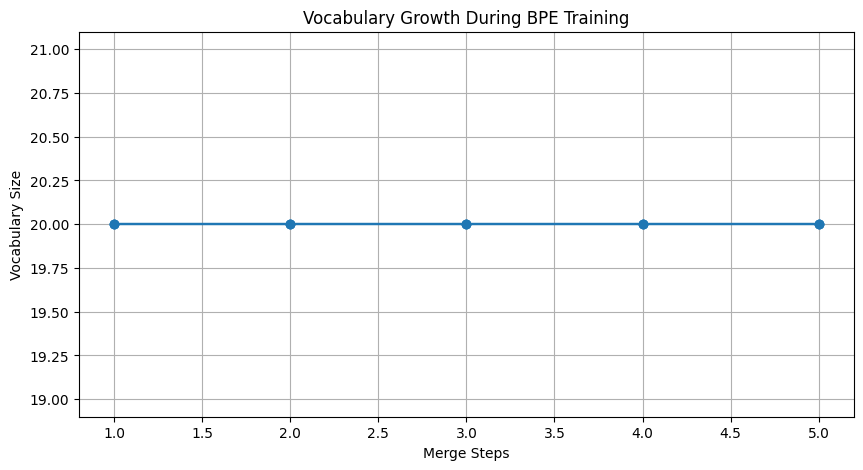

In [ ]:
# Step 6: Enhanced BPE Training with Progress Tracking
# ==============================================
print("\nStep 6: Enhanced BPE Training")
print("-------------------------")

def train_bpe(texts: List[str], num_merges: int = 10) -> List[Tuple[str, str]]:
    """
    Train BPE with progress tracking and vocabulary growth visualization.
    """
    vocab = build_char_vocab(texts)
    merges = []

    # Progress bar for training
    pbar = tqdm(total=num_merges, desc="Training BPE")

    for i in range(num_merges):
        # Count pairs
        pair_counts, _ = count_pairs(texts)
        if not pair_counts:
            break

        # Get most frequent pair
        best_pair = pair_counts.most_common(1)[0][0]
        merges.append(best_pair)

        # Apply merge to all texts
        new_texts = []
        for text in texts:
            tokens = get_character_tokens(text)
            tokens = merge_pair(tokens, best_pair)
            new_texts.append("".join(tokens))
        texts = new_texts

        # Update vocabulary size tracking
        vocab[best_pair[0] + best_pair[1]] = len(vocab)
        vocab_tracker.update(len(vocab), i+1)

        pbar.update(1)
        pbar.set_postfix({'vocab_size': len(vocab)})

    pbar.close()

    # Plot vocabulary growth
    vocab_tracker.plot_growth()

    return merges

# Train BPE on our corpus
print("Training BPE...")
merges = train_bpe(corpus, num_merges=5)

Training BPE...


Training BPE:   0%|          | 0/5 [00:00<?, ?it/s]

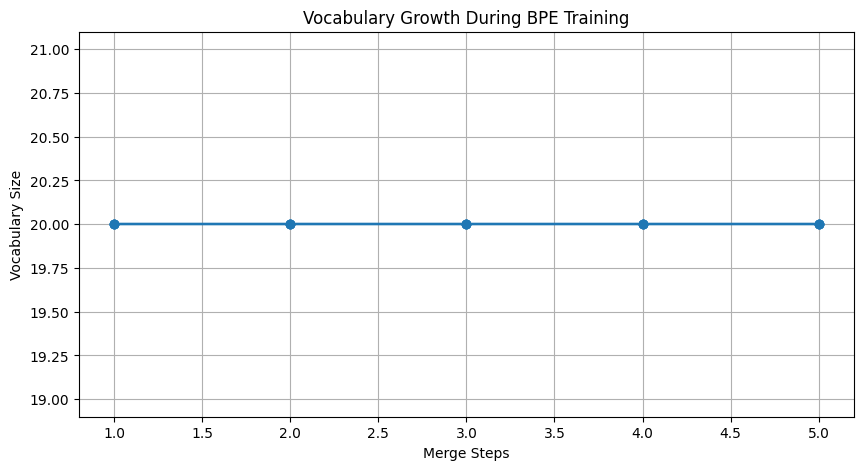


Step 7: GPU-Accelerated Operations
--------------------------------
Testing encoding function:
Original text: hello world
Encoded tokens: ['h', 'e', 'l', 'l', 'o', '_', 'w', 'o', 'r', 'l', 'd']

Example text: hello world
As tensor (on cpu): tensor([ 8,  5, 10, 10, 12,  1, 18, 12, 14, 10,  4])
Shape: torch.Size([11])

Bonus: GPU-Accelerated One-Hot Encoding
------------------------------------
One-hot encoded shape: torch.Size([11, 20])
First token one-hot: tensor([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

Final Statistics
---------------
Final vocabulary size: 20
Number of merges performed: 5

Merge operations performed:
1. Merged 'o' + '_' -> 'o_'
2. Merged 'o' + '_' -> 'o_'
3. Merged 'o' + '_' -> 'o_'
4. Merged 'o' + '_' -> 'o_'
5. Merged 'o' + '_' -> 'o_'


In [ ]:
# Train BPE on our corpus
print("Training BPE...")
merges = train_bpe(corpus, num_merges=5)

# Step 7: GPU-Accelerated Tensor Operations
# ====================================
print("\nStep 7: GPU-Accelerated Operations")
print("--------------------------------")

def encode_text(text: str, merges: List[Tuple[str, str]]) -> List[str]:
    """
    Encode text using learned BPE merges.

    Args:
        text: Input text to encode
        merges: List of merge operations to apply

    Returns:
        List of tokens after applying merges
    """
    # Start with character tokens
    tokens = get_character_tokens(text)

    # Apply each merge operation in sequence
    for merge in merges:
        tokens = merge_pair(tokens, merge)

    return tokens

def create_vocab_from_merges(texts: List[str], merges: List[Tuple[str, str]]) -> Dict[str, int]:
    """Create final vocabulary including merged tokens."""
    vocab = build_char_vocab(texts)
    for first, second in merges:
        merged = first + second
        if merged not in vocab:
            vocab[merged] = len(vocab)
    return vocab

final_vocab = create_vocab_from_merges(corpus, merges)

# Test the encoding function
print("Testing encoding function:")
test_text = "hello world"
encoded_tokens = encode_text(test_text, merges)
print(f"Original text: {test_text}")
print(f"Encoded tokens: {encoded_tokens}")

def text_to_tensor(text: str, vocab: Dict[str, int],
                  merges: List[Tuple[str, str]], device: torch.device) -> torch.Tensor:
    """Convert text to tensor using BPE tokenization with GPU support."""
    tokens = encode_text(text, merges)
    indices = [vocab.get(token, vocab['<UNK>']) for token in tokens]
    return torch.tensor(indices, dtype=torch.long, device=device)

# Convert example text to tensor on GPU if available
example = "hello world"
tensor = text_to_tensor(example, final_vocab, merges, device)
print(f"\nExample text: {example}")
print(f"As tensor (on {device}): {tensor}")
print(f"Shape: {tensor.shape}")

# Bonus: GPU-Accelerated One-Hot Encoding
# ==================================
print("\nBonus: GPU-Accelerated One-Hot Encoding")
print("------------------------------------")

def one_hot_encode(tensor: torch.Tensor, vocab_size: int) -> torch.Tensor:
    """Convert token indices to one-hot vectors with GPU support."""
    return torch.nn.functional.one_hot(tensor, num_classes=vocab_size)

one_hot = one_hot_encode(tensor, len(final_vocab))
print(f"One-hot encoded shape: {one_hot.shape}")
print(f"First token one-hot: {one_hot[0]}")

# Final Statistics and Visualization
# ==============================
print("\nFinal Statistics")
print("---------------")

print(f"Final vocabulary size: {len(final_vocab)}")
print(f"Number of merges performed: {len(merges)}")
print("\nMerge operations performed:")
for i, merge in enumerate(merges, 1):
    print(f"{i}. Merged '{merge[0]}' + '{merge[1]}' -> '{merge[0] + merge[1]}'")